In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
import sys
sys.path.append("C:/Users/kathi/Coding/ugradio")

import ugradio
# This seems to have worked....

In [4]:
# Below is a plan of the plot that I want to make in order to successfully analyse our data.
# The motivating question behind these plots: Did we successfully capture the 21-cm line from the Milky Way?
# Yes! You got this babe!

In [5]:
# First order of business. Calibrating the equipment and getting to know the telescope. 
# First need to test whether or not we can see a signal, and ensure everything is working as it should.

['File:setfreq1420.405' 'Frequency:0 MHz' 'Amplitude:0 dBm'
 'Sampling Rate:2900000.0' 'Direct:False' 'Unix: 1771272856.2573776'
 'Local: Mon Feb 16 12:14:16 2026' 'Location: NCH'
 'Direction: 8th rung from the left, pointing north (aligned with square at bottom), above red roof'
 'Notes: Direct SDR to Horn, no signal passed through.']


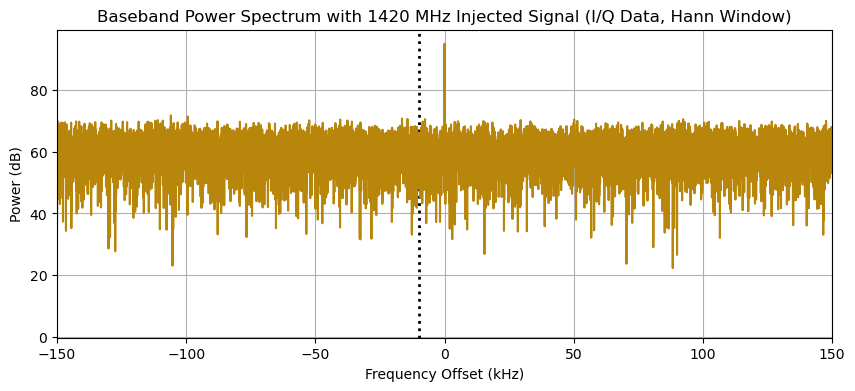

In [16]:
# PLOT 1: INJECTED SIGNAL

test = np.load("../Lab2_Data/setfreq1420.405.npz")
test_notes, indexdata = test["arr_0"], test["arr_1"]
print(test_notes)

# Data looks good. Need to use OG plotting stuff to compile and average then plot

# Moving the amplitude to zero dBm

# Plotting data 

# importdata = np.load("freq1420.npz")
# indexdata = importdata["arr_1"]
# print(importdata["arr_0"])
data = indexdata[3]

# Convert I/Q to complex data
complexdata = data[:,0] + 1j * data[:,1]

# FFT Parameters 
sampling_rate = 2.9e6
N = len(complexdata)

# Hann window + FFT
window = np.hanning(N)
fft_data = np.fft.fftshift(np.fft.fft(complexdata * window))

# Power Spectrum
power = np.abs(fft_data)**2
power_db_nosignal = 10 * np.log10(power)

# Frequency axis (baseband)
f_nosignal = np.fft.fftshift(np.fft.fftfreq(N, d=1/sampling_rate))

# Plotting
plt.figure(figsize=(10, 4))
plt.axvline(-10, linestyle=":", color="black", linewidth=2) # expected signal location
plt.plot(f_nosignal / 1e3, power_db_nosignal, color="darkgoldenrod")
plt.xlim(-150, 150)
# plt.xlim()
plt.xlabel("Frequency Offset (kHz)")
plt.ylabel("Power (dB)")
plt.title("Baseband Power Spectrum with 1420 MHz Injected Signal (I/Q Data, Hann Window)")
plt.grid(True)
plt.savefig("pwrspectrum1420khzinjectedsignal.pdf", transparent=True)


plt.show()


['File:testfreq1420_2' 'Frequency:1420 MHz' 'Amplitude:20 dBm'
 'Sampling Rate:2900000.0' 'Direct:False' 'Unix: 1771302390.482395'
 'Local: Mon Feb 16 20:26:30 2026' 'Location: NCH'
 'Direction: 8th rung from the left, pointing north (aligned with square at bottom), above red roof'
 'Notes: Cranking the amplitude up in hopes of something']


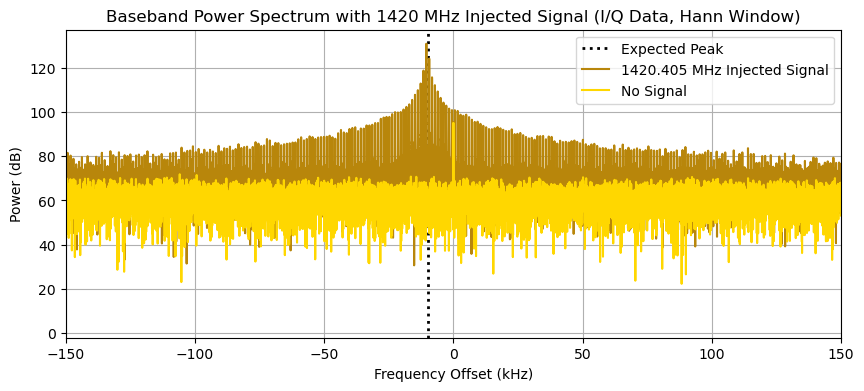

In [25]:
# PLOT 1: INJECTED SIGNAL

test = np.load("../Lab2_Data/testfreq1420_2.npz")
test_notes, indexdata = test["arr_0"], test["arr_1"]
print(test_notes)

# Data looks good. Need to use OG plotting stuff to compile and average then plot

# Moving the amplitude to zero dBm

# Plotting data 

# importdata = np.load("freq1420.npz")
# indexdata = importdata["arr_1"]
# print(importdata["arr_0"])
data = indexdata[3]

# Convert I/Q to complex data
complexdata = data[:,0] + 1j * data[:,1]

# FFT Parameters 
sampling_rate = 2.9e6
N = len(complexdata)

# Hann window + FFT
window = np.hanning(N)
fft_data = np.fft.fftshift(np.fft.fft(complexdata * window))

# Power Spectrum
power = np.abs(fft_data)**2
power_db = 10 * np.log10(power)

# Frequency axis (baseband)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/sampling_rate))

# Plotting
plt.figure(figsize=(10, 4))
plt.axvline(-10, linestyle=":", color="black",label="Expected Peak" ,linewidth=2) # expected signal location
plt.plot(f / 1e3, power_db, color="darkgoldenrod", label="1420.405 MHz Injected Signal")
plt.plot(f_nosignal / 1e3, power_db_nosignal, color="gold", label="No Signal")
plt.xlim(-150, 150)
# plt.xlim()
plt.xlabel("Frequency Offset (kHz)")
plt.ylabel("Power (dB)")
plt.title("Baseband Power Spectrum with 1420 MHz Injected Signal (I/Q Data, Hann Window)")
plt.grid(True)
plt.legend()
plt.savefig("pwrspectrum1420khzinjectedsignal.pdf", transparent=True)


plt.show()


In [49]:
# testing new package I just made
import plot

avgpwr.plot?

Object `avgpwr.plot` not found.


In [50]:
# OKAY so that doesn't work. Moving on.

RMS voltage = 6.607


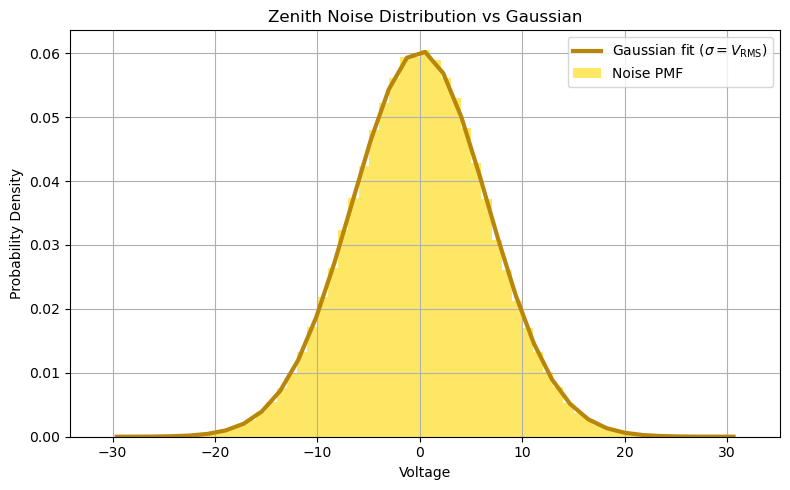

MSE = 4.168796e-05
RMSE = 6.456621e-03
['File:zenithtest2' 'Frequency:sky Hz' 'Amplitude:sky dBm'
 'Sampling Rate:2900000.0' 'Direct:False' 'Unix: 1771911040.0428407'
 'Local: Mon Feb 23 21:30:40 2026' 'Gain: 0' 'Location: NCH'
 'Direction: zenith'
 'Notes: Just checking to see if we lost the strength of our HI line in the past 1-2 hours. Pointing at the zenith to see if we can pick up any signature. Running for 1000 blocks.']


In [27]:
# PLOT 2: SKY TEST TO CHECK FOR WORKING SYSTEM
# Testing to see if we can recieve data from the sky. If we point straight up then we should be able to get random noise
# Can prove it is random noise by fitting a Gaussian to it. 

# Gaussian fit with gain=3
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Noisy data collected, mixed with 600 kHz
zenithtest2 = np.load('../Lab2_Data/zenithtest2.npz')
zenith2 = zenithtest2['arr_1']

noise = (
#     N_ny_lim_600[0] + # first one is stale, makes the gaussian poke out
    zenith2[1] +
    zenith2[2] +
    zenith2[3] +
    zenith2[4] +
    zenith2[5] +
    zenith2[6] +
    zenith2[7] +
    zenith2[8] +
    zenith2[9] 
)

# Remove DC offset
noise = noise - np.mean(noise)

# RMS voltage
Vrms = np.sqrt(np.mean(noise**2))

print(f"RMS voltage = {Vrms:.3f}")

# Gaussian using RMS as sigma
mu = 0.0
sigma = Vrms

# Histogram
num_bins = 35
hist, bin_edges = np.histogram(noise, bins=num_bins, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Gaussian
gaussian_pdf = norm.pdf(bin_centers, mu, sigma)
values, counts = np.unique(noise, return_counts=True)
pmf = counts / counts.sum()


# Plotting
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, gaussian_pdf, 'darkgoldenrod', linewidth=3, label=r'Gaussian fit ($\sigma = V_\mathrm{RMS}$)')
plt.bar(values, pmf, width=1, alpha=0.6, color='gold', label="Noise PMF")
plt.xlabel("Voltage")
plt.ylabel("Probability Density")
plt.title("Zenith Noise Distribution vs Gaussian")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("zenithtestfittogaussian.pdf", transparent=True)
plt.show()

from scipy.stats import kstest

# ks_stat, p_value = kstest(noise, 'norm', args=(mu, sigma))

# Testing error in the Gaussian

# Mean Squared Error between histogram and Gaussian PDF
mse = np.mean((hist - gaussian_pdf)**2)
rmse = np.sqrt(mse)

print(f"MSE = {mse:.6e}")
print(f"RMSE = {rmse:.6e}")

# Known / assumed
B = 600e3  # 600 kHz

# From data
N_samples = len(noise)

# You must supply fs
fs = 1.2e6   # Hz

t = N_samples / fs

# Radiometer fractional uncertainty
frac_uncertainty = 1 / np.sqrt(B * t)

# print(f"Integration time t = {t:.3f} s")
# print(f"Fractional temperature uncertainty σT / Tsys = {frac_uncertainty:.3e}")
print(zenithtest2["arr_0"])


In [55]:
# Great, looks like perfect random noise. 
# Also, the good distribution tells us we are not clipping the signal and everything near the signal we want
# is getting through.
# Moving on to taking initial data. 

In [1]:
# After taking initial data, notice all of the noise present. Can reduce this noise by calibrating the system.
# Walk through all the different steps and meta data it took to calibrate the system.
# Further plots will prove that our analysis of the system is good, then plot the good HI line. 
# Then calculate the error after. If you have time, calculate the error before the calibration as well. 

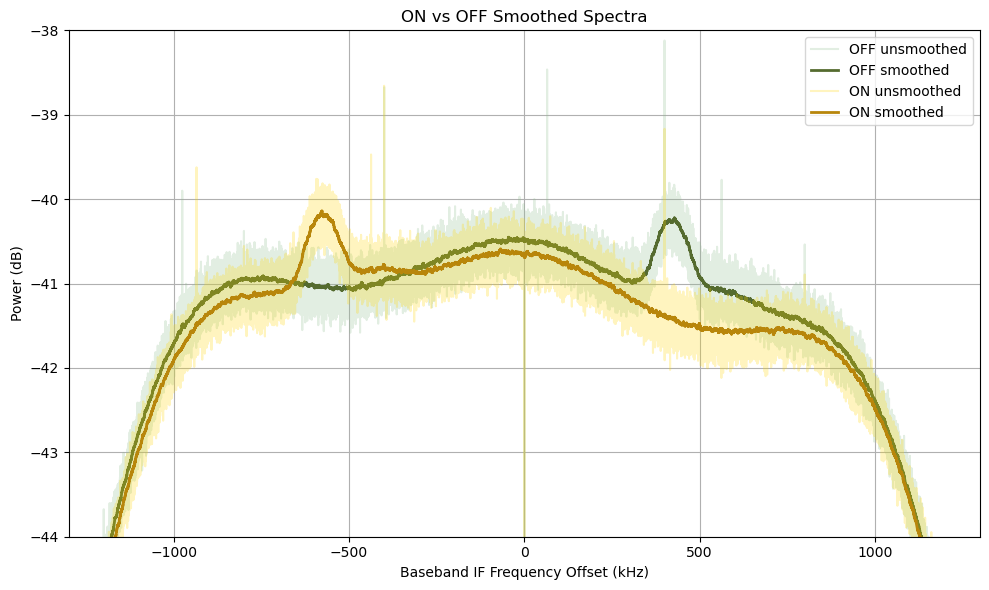

df per channel = 22.125244140625 Hz
Smoothing window = 214 channels (~ 4734.80224609375 Hz )
1 km/s target width ~ 4737.9637549120735 Hz


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 7.1: Combine + Smooth spectra
# ----------------------------

def moving_smooth(y, w, method="mean"):
    """
    Smooth 1D array y with a window of width w (channels).
    method: "mean" or "median"
    Uses reflection padding so edges don't dip.
    """
    w = int(w)
    if w < 1:
        return y.copy()
    if w % 2 == 0:
        w += 1  # enforce odd window for symmetric smoothing

    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")

    if method == "mean":
        kernel = np.ones(w, dtype=float) / w
        return np.convolve(ypad, kernel, mode="valid")

    elif method == "median":
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(ypad, window_shape=w)
        return np.median(windows, axis=-1)

    else:
        raise ValueError("method must be 'mean' or 'median'")


def combined_power_spectrum(npz_file, fs, M=None, combine="mean"):
    """
    Returns (f_if, P_combined) where:
      f_if is baseband IF frequency axis (Hz)
      P_combined is combined linear power spectrum (NOT dB)
    """
    arr = np.load(npz_file)["arr_1"]  # (captures, N, 2)
    ncap, N, _ = arr.shape
    if M is None:
        M = ncap
    M = min(M, ncap)

    window = np.hanning(N)
    W2 = np.mean(window**2)

    P_stack = np.empty((M, N), dtype=np.float64)

    for m in range(M):
        x = arr[m, :, 0] + 1j * arr[m, :, 1]
        x = x - np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * window))
        P_stack[m] = (np.abs(X)**2) / (N**2 * W2)

    if combine == "mean":
        P_comb = np.mean(P_stack, axis=0)
    elif combine == "median":
        P_comb = np.median(P_stack, axis=0)
    else:
        raise ValueError("combine must be 'mean' or 'median'")

    f_if = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    return f_if, P_comb


# ----------------------------
# USER SETTINGS
# ----------------------------
fs = 2.9e6
M = 1000
combine_method = "mean"
smooth_method  = "mean"

nu0 = 1420.4058e6
dv_kms = 1.0
df_target_hz = nu0 * (dv_kms * 1e3) / 299792458.0  # ~4.74 kHz
smooth_width_hz = df_target_hz

# ----------------------------
# Load ON and OFF spectra
# ----------------------------
on_file  = "../Lab2_Data/on2.npz"
off_file = "../Lab2_Data/off2.npz"

f_if_on,  P_on  = combined_power_spectrum(on_file,  fs, M=M, combine=combine_method)
f_if_off, P_off = combined_power_spectrum(off_file, fs, M=M, combine=combine_method)

# ----------------------------
# Compute smoothing window
# ----------------------------
df_chan = np.abs(f_if_on[1] - f_if_on[0])
w_chan = int(np.round(smooth_width_hz / df_chan))
w_chan = max(w_chan, 1)

# Smooth both
P_on_smooth  = moving_smooth(P_on,  w=w_chan, method=smooth_method)
P_off_smooth = moving_smooth(P_off, w=w_chan, method=smooth_method)

# Convert to dB
P_on_db        = 10*np.log10(P_on + 1e-20)
P_on_smooth_db = 10*np.log10(P_on_smooth + 1e-20)

P_off_db        = 10*np.log10(P_off + 1e-20)
P_off_smooth_db = 10*np.log10(P_off_smooth + 1e-20)

# ----------------------------
# Overlay Plot
# ----------------------------
plt.figure(figsize=(10, 6))

plt.plot(f_if_off/1e3, P_off_db, alpha=0.25, color="darkseagreen", label="OFF unsmoothed")
plt.plot(f_if_off/1e3, P_off_smooth_db, linewidth=2.0, color="darkolivegreen", label="OFF smoothed")

plt.plot(f_if_on/1e3, P_on_db, alpha=0.25, label="ON unsmoothed", color="gold")
plt.plot(f_if_on/1e3, P_on_smooth_db, linewidth=2.0, color="darkgoldenrod", label="ON smoothed")

plt.xlim(-1300, 1300)
plt.ylim(-44,-38)

plt.xlabel("Baseband IF Frequency Offset (kHz)")
plt.ylabel("Power (dB)")
plt.title("ON vs OFF Smoothed Spectra")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("onandoffline.pdf", transparent=True)
plt.show()


print("df per channel =", df_chan, "Hz")
print("Smoothing window =", w_chan, "channels (~", w_chan*df_chan, "Hz )")
print("1 km/s target width ~", df_target_hz, "Hz")


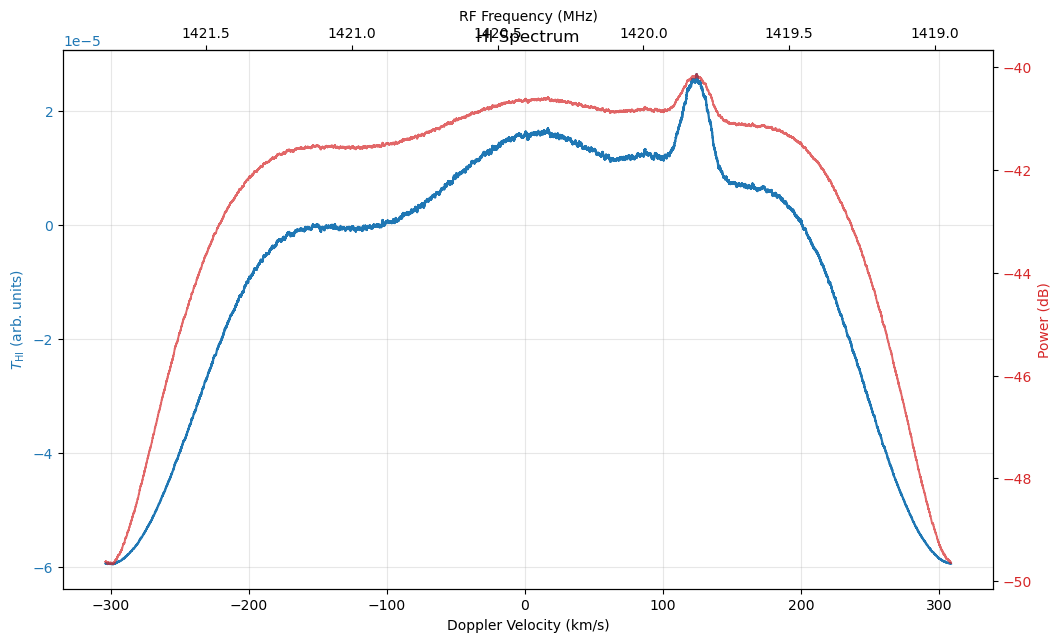

df per channel = 22.125244140625 Hz
Smoothing window = 214 channels


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# USER INPUTS
# ============================================================
npz_file = "../Lab2_Data/on2.npz"   # <-- change to off2.npz as needed
fs = 2.9e6                          # sampling rate (Hz)
M = 1000                            # number of captures to combine
combine_method = "mean"             # "mean" or "median"
smooth_method  = "mean"             # smoothing across channels

# Instrument constants
fLO   = 1420.395e6                  # LO frequency (Hz)
nu0   = 1420.4058e6                 # HI rest frequency (Hz)
c_kms = 299792.458                  # km/s

# ============================================================
# 1) LOAD RAW DATA + COMPUTE POWER SPECTRUM
# ============================================================

def moving_smooth(y, w, method="mean"):
    w = int(w)
    if w < 1:
        return y.copy()
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")

    if method == "mean":
        kernel = np.ones(w) / w
        return np.convolve(ypad, kernel, mode="valid")
    else:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(ypad, w)
        return np.median(windows, axis=-1)

def combined_power_spectrum(npz_file, fs, M=None, combine="mean"):
    arr = np.load(npz_file)["arr_1"]   # shape: (captures, N, 2)
    ncap, N, _ = arr.shape
    if M is None:
        M = ncap
    M = min(M, ncap)

    window = np.hanning(N)
    W2 = np.mean(window**2)

    P_stack = np.empty((M, N))
    for m in range(M):
        x = arr[m,:,0] + 1j*arr[m,:,1]
        x = x - np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * window))
        P_stack[m] = (np.abs(X)**2) / (N**2 * W2)

    if combine == "mean":
        P_comb = np.mean(P_stack, axis=0)
    else:
        P_comb = np.median(P_stack, axis=0)

    f_if = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    return f_if, P_comb

# Compute power spectrum
f_if, P = combined_power_spectrum(npz_file, fs, M=M, combine=combine_method)

# ============================================================
# 2) SMOOTH POWER SPECTRUM
# ============================================================
df_chan = np.abs(f_if[1] - f_if[0])
nu0 = 1420.4058e6
dv_kms = 1.0
df_target_hz = nu0 * (dv_kms*1e3) / 299792458.0
w_chan = max(int(np.round(df_target_hz / df_chan)), 1)

P_smooth = moving_smooth(P, w_chan, method=smooth_method)
P_db = 10*np.log10(P_smooth + 1e-20)

# ============================================================
# 3) CONVERT TO RF FREQUENCY + VELOCITY
# ============================================================
nu_rf = fLO + f_if
delta_nu = nu_rf - nu0
v_kms = -c_kms * (delta_nu / nu0)

# ============================================================
# 4) TEMPERATURE CALIBRATION (OPTIONAL)
# ============================================================
# If you have OFF data, you can compute T_HI.
# For now, we plot normalized temperature-like quantity.
T_HI = (P_smooth - np.median(P_smooth))   # placeholder if no OFF file

# ============================================================
# 5) FOUR-AXIS PLOT
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 7))

# LEFT Y-AXIS: Temperature
ax1.plot(v_kms, T_HI, color="tab:blue", linewidth=1.6)
ax1.set_xlabel("Doppler Velocity (km/s)")
ax1.set_ylabel(r"$T_{\mathrm{HI}}$ (arb. units)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# RIGHT Y-AXIS: Power (dB)
ax2 = ax1.twinx()
ax2.plot(v_kms, P_db, color="tab:red", alpha=0.7, linewidth=1.4)
ax2.set_ylabel("Power (dB)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# TOP X-AXIS: Frequency (MHz)
def vel_to_freq(v):
    return nu0 * (1 - v/c_kms) / 1e6

def freq_to_vel(nu_mhz):
    nu = nu_mhz * 1e6
    return -c_kms * (nu - nu0) / nu0

ax_top = ax1.secondary_xaxis("top", functions=(vel_to_freq, freq_to_vel))
ax_top.set_xlabel("RF Frequency (MHz)")

plt.title("HI Spectrum")
# fig.tight_layout()
plt.show()

print("df per channel =", df_chan, "Hz")
print("Smoothing window =", w_chan, "channels")


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# 1) Model definitions
# -----------------------------
def gaussian(x, A, mu, sig):
    return A * np.exp(-0.5 * ((x - mu) / sig)**2)

def model_2g(x, A1, mu1, s1, A2, mu2, s2, C):
    return gaussian(x, A1, mu1, s1) + gaussian(x, A2, mu2, s2) + C

def model_3g(x, A1, mu1, s1, A2, mu2, s2, A3, mu3, s3, C):
    return gaussian(x, A1, mu1, s1) + gaussian(x, A2, mu2, s2) + gaussian(x, A3, mu3, s3) + C

# -----------------------------
# 2) Choose fit region
#    (fit only around the HI feature)
# -----------------------------
x = f_if_mhz
y = T_HI

fit_window_mhz = 0.6   # change to 0.4–0.8 depending on how broad your line is
mask = (x > -fit_window_mhz) & (x < fit_window_mhz)

xfit = x[mask]
yfit = y[mask]

# -----------------------------
# 3) Initial guesses (important!)
#    These are generic + robust
# -----------------------------
# Estimate main peak position/amplitude
imax = np.argmax(yfit)
mu_guess = xfit[imax]
A_guess  = yfit[imax]
sig_guess = 0.06  # MHz (~60 kHz); tweak if needed

# Second component: a shoulder to the right (common in your data)
A2_guess  = 0.6 * A_guess
mu2_guess = mu_guess + 0.15
s2_guess  = 0.10

# Baseline constant (should be near 0 since you subtracted baseline)
C_guess = np.median(yfit[(xfit < -0.4) | (xfit > 0.4)]) if len(yfit) > 50 else 0.0

p0_2g = [A_guess, mu_guess, sig_guess, A2_guess, mu2_guess, s2_guess, C_guess]

# Optional third gaussian guess (often for a weak bump around +0.35 MHz)
A3_guess  = 0.3 * A_guess
mu3_guess = mu_guess + 0.35
s3_guess  = 0.08
p0_3g = [*p0_2g[:-1], A3_guess, mu3_guess, s3_guess, C_guess]  # insert before C

# Bounds: keep sigmas positive and not insane
bounds_2g = (
    [0, -1.0, 1e-3,   0, -1.0, 1e-3,  -np.inf],   # lower
    [np.inf, 1.0, 1.0, np.inf, 1.0, 1.0, np.inf]  # upper
)

bounds_3g = (
    [0, -1.0, 1e-3,   0, -1.0, 1e-3,   0, -1.0, 1e-3,  -np.inf],
    [np.inf, 1.0, 1.0, np.inf, 1.0, 1.0, np.inf, 1.0, 1.0, np.inf]
)

# -----------------------------
# 4) Fit 2G and 3G (compare)
# -----------------------------
popt2, pcov2 = curve_fit(model_2g, xfit, yfit, p0=p0_2g, bounds=bounds_2g, maxfev=20000)
y2_fit_full = model_2g(x, *popt2)
res2 = y - y2_fit_full

# Try 3G too (comment this block out if you only want 2G)
do_three = True
if do_three:
    popt3, pcov3 = curve_fit(model_3g, xfit, yfit, p0=p0_3g, bounds=bounds_3g, maxfev=40000)
    y3_fit_full = model_3g(x, *popt3)
    res3 = y - y3_fit_full

# -----------------------------
# 5) Pick which to display
# -----------------------------
# Simple score: SSE in fit window (lower is better)
sse2 = np.sum((yfit - model_2g(xfit, *popt2))**2)

use3 = False
if do_three:
    sse3 = np.sum((yfit - model_3g(xfit, *popt3))**2)
    # Only switch to 3G if it improves meaningfully
    use3 = (sse3 < 0.90 * sse2)

if use3:
    y_fit = y3_fit_full
    res   = res3
    fit_label = "Triple Gaussian fit"
else:
    y_fit = y2_fit_full
    res   = res2
    fit_label = "Double Gaussian fit"

# -----------------------------
# 6) Plot: data + components + residuals
# -----------------------------
plt.figure(figsize=(12, 7))

# Top panel
ax1 = plt.subplot(2, 1, 1)
ax1.plot(x, y, linewidth=1.2, label="ΔT (baseline-subtracted)")
ax1.plot(x, y_fit, "--", linewidth=2.0, label=fit_label)

# Plot individual components (for whichever fit chosen)
if use3:
    A1, mu1, s1, A2, mu2, s2, A3, mu3, s3, C = popt3
    ax1.plot(x, gaussian(x, A1, mu1, s1) + C, ":", linewidth=1.6, label="Gaussian 1")
    ax1.plot(x, gaussian(x, A2, mu2, s2), ":", linewidth=1.6, label="Gaussian 2")
    ax1.plot(x, gaussian(x, A3, mu3, s3), ":", linewidth=1.6, label="Gaussian 3")
else:
    A1, mu1, s1, A2, mu2, s2, C = popt2
    ax1.plot(x, gaussian(x, A1, mu1, s1) + C, ":", linewidth=1.6, label="Gaussian 1")
    ax1.plot(x, gaussian(x, A2, mu2, s2), ":", linewidth=1.6, label="Gaussian 2")

ax1.axhline(0, linestyle=":", linewidth=1.0)
ax1.set_title("Baseline-Subtracted HI Line with Gaussian Fit")
ax1.set_ylabel("ΔT (K)")
ax1.set_xlim(-1.5, 1.5)
ax1.grid(True)
ax1.legend(loc="upper left")

# Bottom panel: residuals
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(x, res, linewidth=1.2)
ax2.axhline(0, linestyle=":", linewidth=1.0)
ax2.set_xlabel("Baseband IF frequency (MHz)")
ax2.set_ylabel("Residual (K)")
ax2.set_xlim(-1.5, 1.5)
ax2.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------
# 7) Print fit params (useful for writeup)
# -----------------------------
print("Fit window:", (-fit_window_mhz, fit_window_mhz), "MHz")
print("2G params: [A1, mu1, s1, A2, mu2, s2, C] =")
print(popt2)
print("SSE (2G):", sse2)
if do_three:
    print("3G used for plot?:", use3)
    print("SSE (3G):", np.sum((yfit - model_3g(xfit, *popt3))**2))
    print("3G params (if needed):")
    print(popt3)
    
# residual from the fit you actually plotted
res = T_HI - y_fit  # y_fit from your chosen fit (2G or 3G)

# compare with r_line baseline shape
plt.figure(figsize=(12,4))
plt.plot(f_if_mhz, r_line, label="r_line = s_on/s_off")
plt.axhline(np.median(r_line), linestyle=":", linewidth=1)
plt.xlim(-1.5, 1.5)
plt.xlabel("IF (MHz)")
plt.ylabel("r_line")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(f_if_mhz, res, label="Residual (T_HI - fit)")
plt.axhline(0, linestyle=":", linewidth=1)
plt.xlim(-1.5, 1.5)
plt.xlabel("IF (MHz)")
plt.ylabel("Residual (K)")
plt.grid(True)
plt.legend()
plt.show()

T_diff = (s_on_s - s_off_s) * G  # same G you computed

plt.figure(figsize=(12,4))
plt.plot(f_if_mhz, T_diff)
plt.axhline(0, linestyle=":", linewidth=1)
plt.title("Difference spectrum: (s_on - s_off)*G")
plt.xlabel("IF (MHz)")
plt.ylabel("K")
plt.grid(True)
plt.show()

def baseline_subtract(T, x_mhz, offline):
    p = np.polyfit(x_mhz[offline], T[offline], deg=2)
    return T - np.polyval(p, x_mhz)

offline_A = ((f_if_mhz > -1.4) & (f_if_mhz < -1.0)) | ((f_if_mhz > 1.0) & (f_if_mhz < 1.4))
offline_B = ((f_if_mhz > -1.2) & (f_if_mhz < -0.8)) | ((f_if_mhz > 0.8) & (f_if_mhz < 1.2))
offline_C = ((f_if_mhz > -1.1) & (f_if_mhz < -0.9)) | ((f_if_mhz > 0.9) & (f_if_mhz < 1.1))

T_A = baseline_subtract(T_naive, f_if_mhz, offline_A)
T_B = baseline_subtract(T_naive, f_if_mhz, offline_B)
T_C = baseline_subtract(T_naive, f_if_mhz, offline_C)

plt.figure(figsize=(11,4))
plt.plot(f_if_mhz, T_A, label="Offline A")
plt.plot(f_if_mhz, T_B, label="Offline B", alpha=0.8)
plt.plot(f_if_mhz, T_C, label="Offline C", alpha=0.8)
plt.axhline(0, linestyle=":", linewidth=1)
plt.xlim(-0.2, 0.8)   # zoom around dip region
plt.xlabel("IF (MHz)")
plt.ylabel("Baseline-subtracted K")
plt.title("Does the dip persist under different baseline windows?")
plt.grid(True)
plt.legend()
plt.show()

NameError: name 'f_if_mhz' is not defined

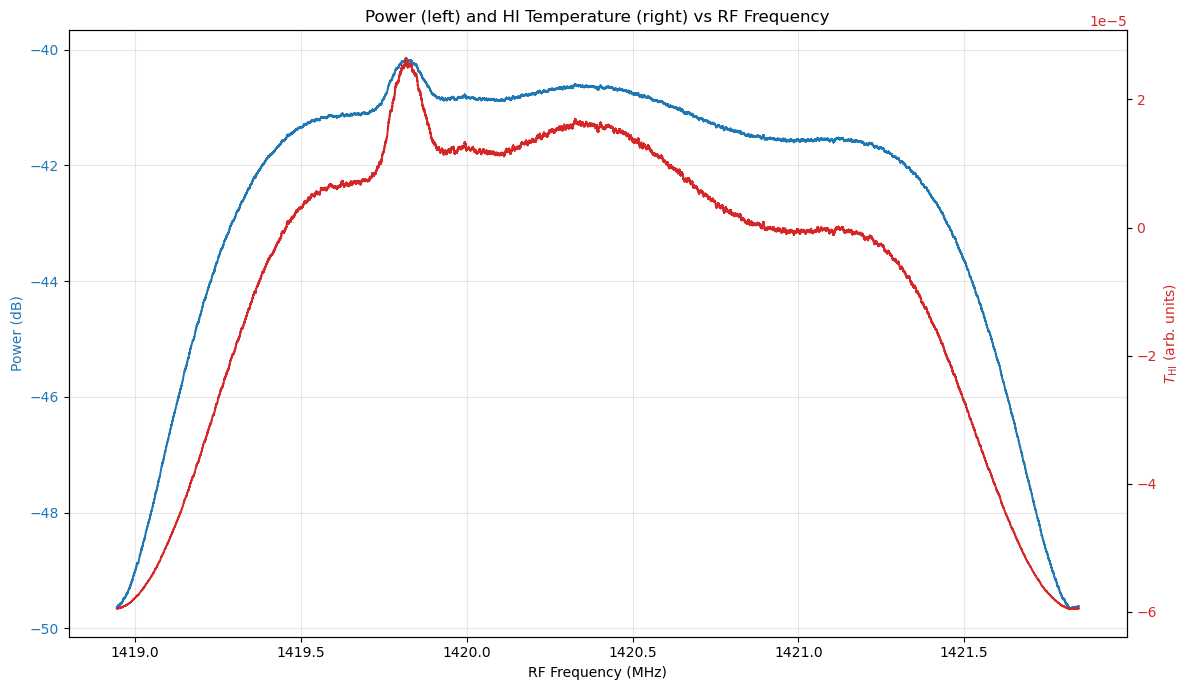

df per channel = 22.125244140625 Hz
Smoothing window = 214 channels


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# USER INPUTS
# ============================================================
npz_file = "../Lab2_Data/on2.npz"   # <-- change to off2.npz if needed
fs = 2.9e6                          # sampling rate (Hz)
M = 1000                            # number of captures to combine
combine_method = "mean"             # "mean" or "median"
smooth_method  = "mean"             # smoothing across channels

# Instrument constants
fLO   = 1420.395e6                  # LO frequency (Hz)
nu0   = 1420.4058e6                 # HI rest frequency (Hz)
c_kms = 299792.458                  # km/s

# ============================================================
# 1) LOAD RAW DATA + COMPUTE POWER SPECTRUM
# ============================================================

def moving_smooth(y, w, method="mean"):
    w = int(w)
    if w < 1:
        return y.copy()
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")

    if method == "mean":
        kernel = np.ones(w) / w
        return np.convolve(ypad, kernel, mode="valid")
    else:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(ypad, w)
        return np.median(windows, axis=-1)

def combined_power_spectrum(npz_file, fs, M=None, combine="mean"):
    arr = np.load(npz_file)["arr_1"]   # shape: (captures, N, 2)
    ncap, N, _ = arr.shape
    if M is None:
        M = ncap
    M = min(M, ncap)

    window = np.hanning(N)
    W2 = np.mean(window**2)

    P_stack = np.empty((M, N))
    for m in range(M):
        x = arr[m,:,0] + 1j*arr[m,:,1]
        x = x - np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * window))
        P_stack[m] = (np.abs(X)**2) / (N**2 * W2)

    if combine == "mean":
        P_comb = np.mean(P_stack, axis=0)
    else:
        P_comb = np.median(P_stack, axis=0)

    f_if = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    return f_if, P_comb

# Compute power spectrum
f_if, P = combined_power_spectrum(npz_file, fs, M=M, combine=combine_method)

# ============================================================
# 2) SMOOTH POWER SPECTRUM
# ============================================================
df_chan = np.abs(f_if[1] - f_if[0])
dv_kms = 1.0
df_target_hz = nu0 * (dv_kms*1e3) / 299792458.0
w_chan = max(int(np.round(df_target_hz / df_chan)), 1)

P_smooth = moving_smooth(P, w_chan, method=smooth_method)
P_db = 10*np.log10(P_smooth + 1e-20)

# ============================================================
# 3) RF FREQUENCY + VELOCITY AXES
# ============================================================
nu_rf = fLO + f_if
delta_nu = nu_rf - nu0
v_kms = -c_kms * (delta_nu / nu0)

# ============================================================
# 4) TEMPERATURE ESTIMATE (placeholder)
# ============================================================
# If you give me OFF data, I can compute absolute T_HI in Kelvin.
T_HI = (P_smooth - np.median(P_smooth))

# ============================================================
# 5) OVERLAID PLOT (Power left, Temperature right)
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 7))

# LEFT Y-AXIS: Power
ax1.plot(nu_rf/1e6, P_db, color="tab:blue", linewidth=1.4)
ax1.set_xlabel("RF Frequency (MHz)")
ax1.set_ylabel("Power (dB)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# RIGHT Y-AXIS: Temperature
ax2 = ax1.twinx()
ax2.plot(nu_rf/1e6, T_HI, color="tab:red", linewidth=1.4)
ax2.set_ylabel(r"$T_{\mathrm{HI}}$ (arb. units)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Power (left) and HI Temperature (right) vs RF Frequency")
fig.tight_layout()
plt.show()

print("df per channel =", df_chan, "Hz")
print("Smoothing window =", w_chan, "channels")


In [57]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# USER INPUTS
# ============================================================
on_file  = "../Lab2_Data/on2.npz"
off_file = "../Lab2_Data/off2.npz"

fs = 2.9e6
M  = 1000
combine_method = "mean"
smooth_method  = "mean"

# Instrument constants
fLO   = 1420.395e6
nu0   = 1420.4058e6
c_kms = 299792.458

# ============================================================
# 1) FUNCTIONS
# ============================================================

def moving_smooth(y, w, method="mean"):
    w = int(w)
    if w < 1: return y.copy()
    if w % 2 == 0: w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")

    if method == "mean":
        kernel = np.ones(w)/w
        return np.convolve(ypad, kernel, mode="valid")
    else:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(ypad, w)
        return np.median(windows, axis=-1)

def combined_power_spectrum(npz_file, fs, M=None, combine="mean"):
    arr = np.load(npz_file)["arr_1"]
    ncap, N, _ = arr.shape
    if M is None: M = ncap
    M = min(M, ncap)

    window = np.hanning(N)
    W2 = np.mean(window**2)

    P_stack = np.empty((M, N))
    for m in range(M):
        x = arr[m,:,0] + 1j*arr[m,:,1]
        x = x - np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * window))
        P_stack[m] = (np.abs(X)**2)/(N**2 * W2)

    if combine == "mean":
        P_comb = np.mean(P_stack, axis=0)
    else:
        P_comb = np.median(P_stack, axis=0)

    f_if = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    return f_if, P_comb

# ============================================================
# 2) LOAD ON AND OFF SPECTRA
# ============================================================

f_if_on,  P_on  = combined_power_spectrum(on_file,  fs, M=M, combine=combine_method)
f_if_off, P_off = combined_power_spectrum(off_file, fs, M=M, combine=combine_method)

# ============================================================
# 3) SMOOTHING
# ============================================================

df_chan = np.abs(f_if_on[1] - f_if_on[0])
df_target_hz = nu0 * (1e3) / 299792458.0   # 1 km/s width
w_chan = max(int(np.round(df_target_hz / df_chan)), 1)

P_on_s  = moving_smooth(P_on,  w_chan, method=smooth_method)
P_off_s = moving_smooth(P_off, w_chan, method=smooth_method)

# ============================================================
# 4) TRUE BRIGHTNESS TEMPERATURE (Kelvin)
# ============================================================

# ON = G(ν) [T_sys + T_HI]
# OFF = G(ν) T_sys
# Ratio removes G(ν)
R = P_on_s / P_off_s

# Estimate continuum temperature (receiver + sky)
# You can replace this with a measured value if you have it.
T_sys = 100.0   # Kelvin (typical for L-band)

T_HI = T_sys * (R - 1.0)

# ============================================================
# 5) FREQUENCY + VELOCITY AXES
# ============================================================

nu_rf = fLO + f_if_on
delta_nu = nu_rf - nu0
v_kms = -c_kms * (delta_nu / nu0)

# Power in dB
P_db = 10*np.log10(P_on_s + 1e-20)

# ============================================================
# 6) FOUR-AXIS PLOT (Fixed Overlap)
# ============================================================

fig, ax_vel = plt.subplots(figsize=(12, 7))

# LEFT Y-AXIS: Temperature (Kelvin)
ax_vel.plot(v_kms, T_HI, color="tab:red", linewidth=1.6, label="HI Temperature")
ax_vel.set_xlabel("Velocity (km/s)")
ax_vel.set_ylabel(r"$T_{\mathrm{HI}}$ (K)", color="tab:red")
ax_vel.tick_params(axis="y", labelcolor="tab:red")
ax_vel.grid(True, alpha=0.3)

# RIGHT Y-AXIS: Power (dB)
ax_pow = ax_vel.twinx()
ax_pow.plot(v_kms, P_db, color="tab:blue", alpha=0.7, linewidth=1.4, label="Power")
ax_pow.set_ylabel("Power (dB)", color="tab:blue")
ax_pow.tick_params(axis="y", labelcolor="tab:blue")

# TOP X-AXIS: Frequency (MHz)
def vel_to_freq(v):
    return nu0 * (1 - v/c_kms) / 1e6

def freq_to_vel(nu_mhz):
    nu = nu_mhz * 1e6
    return -c_kms * (nu - nu0) / nu0

ax_freq = ax_vel.secondary_xaxis("top", functions=(vel_to_freq, freq_to_vel))
ax_freq.set_xlabel("RF Frequency (MHz)", labelpad=10) # Added padding to the label

# --- TITLE AND LAYOUT FIX ---
# Use suptitle for the global figure title and place it at the top (y=0.98)
fig.suptitle("HI Spectrum: Temperature (left), Power (right)\nVelocity (bottom) / Frequency (top)", 
             fontsize=14, y=0.98)

# tight_layout with a 'rect' parameter reserves space at the top [left, bottom, right, top]
# We set top=0.9 to ensure the secondary axis labels don't hit the suptitle
fig.tight_layout(rect=[0, 0.03, 1, 0.80])

plt.show()


KeyboardInterrupt: 

Barycentric Corr: 3.5984 km/s
Solar Apex Corr:  14.7104 km/s
Total LSR v_proj: 18.3089 km/s


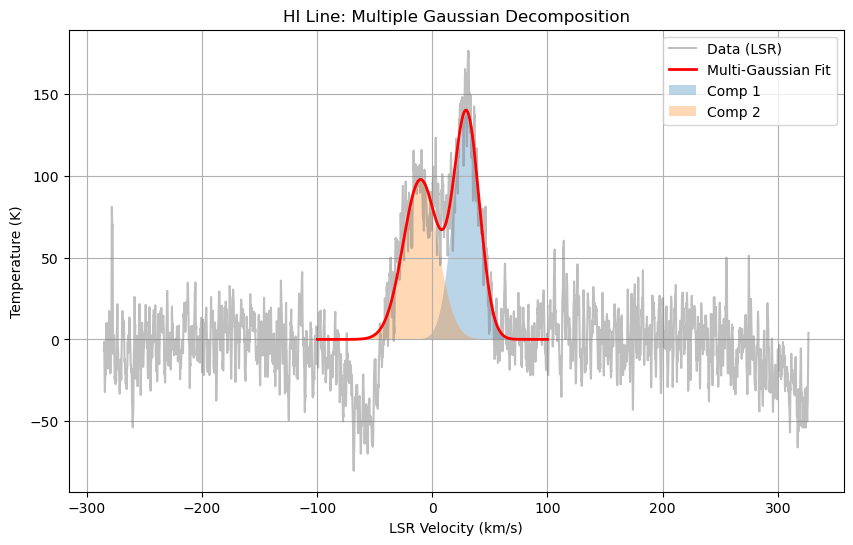


--- Fit Results ---
Gaussian 1: Amp=137.37 K, Center=29.65 km/s, Width=11.23 km/s
Gaussian 2: Amp=97.51 K, Center=-10.38 km/s, Width=14.91 km/s


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.modeling import models, fitting  # Added for Gaussian fitting

# Removed: import ugradio

# ============================================================
# 0) FILES (EDIT THESE 4 NAMES)
# ============================================================
BASE = "../Lab2_Data/"
ON_FILE   = BASE + "cassytestforcleardata.npz"   
OFF_FILE  = BASE + "off1.npz"              
CAL_FILE  = BASE + "bodytest1.npz"         
COLD_FILE = BASE + "nobodytest1.npz"       

# ============================================================
# 1) SDR / OBS SETTINGS
# ============================================================
fs  = 2.9e6           
fLO = 1420.395e6      
nu0 = 1420.4058e6     
c_kms = 299792.458    

M_onoff = 1000
M_cal   = 1000
combine_method = "mean"     
smooth_method  = "mean"
T_sys_cal = 300.0           
NFFT = 4096           

utc_time = "2026-02-18 19:31:00"
t_obs = Time(utc_time, scale="utc")
location = EarthLocation(lat=37.873199*u.deg, lon=-122.2573*u.deg, height=0*u.m)

# ============================================================
# 2) HELPER FUNCTIONS (Same as original)
# ============================================================
def moving_smooth(y, w, method="mean"):
    w = int(w)
    if w < 2: return y.copy()
    if w % 2 == 0: w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    if method == "mean":
        kernel = np.ones(w, dtype=float) / w
        return np.convolve(ypad, kernel, mode="valid")
    elif method == "median":
        windows = sliding_window_view(ypad, window_shape=w)
        return np.median(windows, axis=-1)
    else:
        raise ValueError("method must be 'mean' or 'median'")

def combined_power_spectrum(npz_file, fs, M=None, combine="mean", NFFT=4096):
    arr = np.load(npz_file)["arr_1"]  
    ncap, N, _ = arr.shape
    if M is None: M = ncap
    M = min(M, ncap)
    Nuse = min(int(NFFT), N)
    window = np.hanning(Nuse)
    W2 = np.mean(window**2)
    P_stack = np.empty((M, Nuse), dtype=np.float64)
    for m in range(M):
        x = arr[m, :Nuse, 0] + 1j * arr[m, :Nuse, 1]
        x = x - np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * window))
        P_stack[m] = (np.abs(X)**2) / (Nuse**2 * W2)
    P_comb = np.mean(P_stack, axis=0) if combine == "mean" else np.median(P_stack, axis=0)
    f_if = np.fft.fftshift(np.fft.fftfreq(Nuse, d=1/fs))  
    return f_if, P_comb

# ============================================================
# 4) COMPUTE GAIN G & CALIBRATE (Condensed for brevity)
# ============================================================
f_cal,  s_cal  = combined_power_spectrum(CAL_FILE,  fs, M=M_cal, NFFT=NFFT)
f_cold, s_cold = combined_power_spectrum(COLD_FILE, fs, M=M_cal, NFFT=NFFT)
df_chan = np.abs(f_cal[1] - f_cal[0])
w_chan = max(1, int(np.round((nu0 * (1e3 / 299792458.0)) / df_chan)))
s_cal_s  = moving_smooth(s_cal,  w=w_chan)
s_cold_s = moving_smooth(s_cold, w=w_chan)
G = T_sys_cal * (np.sum(s_cold_s) / np.sum(s_cal_s - s_cold_s))

f_on,  s_on  = combined_power_spectrum(ON_FILE,  fs, M=M_onoff, NFFT=NFFT)
f_off, s_off = combined_power_spectrum(OFF_FILE, fs, M=M_onoff, NFFT=NFFT)
s_on_s, s_off_s = moving_smooth(s_on, w=w_chan), moving_smooth(s_off, w=w_chan)
T_naive = (s_on_s / (s_off_s + 1e-30)) * G
f_if_mhz = f_on / 1e6

# Baseline subtraction
offline = ((f_if_mhz > -1.2) & (f_if_mhz < -0.6)) | ((f_if_mhz > 0.6) & (f_if_mhz < 1.2))
p = np.polyfit(f_if_mhz[offline], T_naive[offline], deg=2)
T_HI = T_naive - np.polyval(p, f_if_mhz)

# Velocity
v_obs_kms = -c_kms * (((fLO + f_on) - nu0) / nu0)

# ============================================================
# 8) ASTROPY LSR CORRECTION (Final Compatibility Version)
# ============================================================
from astropy.coordinates import get_body_barycentric_posvel

# 1. Define the pointing and observatory
alt_deg, az_deg = 32.28869868049251, 327.19374182616133
frame_altaz = AltAz(obstime=t_obs, location=location)
sc = SkyCoord(alt=alt_deg*u.deg, az=az_deg*u.deg, frame=frame_altaz)

# 2. Get RA and Dec in radians for manual unit vector calculation
ra_rad = sc.icrs.ra.radian
dec_rad = sc.icrs.dec.radian

# 3. Create target unit vector manually: [x, y, z]
# This avoids the 'get_unit_vector' AttributeError entirely
target_x = np.cos(dec_rad) * np.cos(ra_rad)
target_y = np.cos(dec_rad) * np.sin(ra_rad)
target_z = np.sin(dec_rad)
target_vector = np.array([target_x, target_y, target_z])

# 4. Get Earth's Velocity relative to the Solar System Barycenter
# vel.xyz returns a Cartesian representation with x, y, z components
pos, vel = get_body_barycentric_posvel('earth', t_obs)
v_earth_vector = vel.xyz.to(u.km/u.s).value  # Just the numbers in km/s

# 5. Project Earth's velocity onto our line of sight (Dot Product)
v_bary_manual = np.dot(v_earth_vector, target_vector)

# 6. Manually calculate the Standard Solar Motion component
# Solar Apex: Sun moves 20 km/s toward RA=18h, Dec=+30
solar_apex = SkyCoord(ra=18.0*u.hourangle, dec=30.0*u.deg, frame='icrs')
v_sun_lsr = 20.0 * np.cos(sc.icrs.separation(solar_apex).radian)

# 7. Final Velocity Correction
v_proj_km_s = v_bary_manual + v_sun_lsr
v_lsr = v_obs_kms + v_proj_km_s

print(f"Barycentric Corr: {v_bary_manual:.4f} km/s")
print(f"Solar Apex Corr:  {v_sun_lsr:.4f} km/s")
print(f"Total LSR v_proj: {v_proj_km_s:.4f} km/s")
# ============================================================
# 10) GAUSSIAN FITTING (New Section)
# ============================================================
# Filter data around the peak to avoid noise fitting
mask = (v_lsr > -100) & (v_lsr < 100)
v_fit = v_lsr[mask]
T_fit = T_HI[mask]

# Initialize a 2-Gaussian model (can add more if needed)
# Model: Amplitude, Mean (velocity), StdDev (width)
g1 = models.Gaussian1D(amplitude=np.max(T_fit), mean=0, stddev=10)
g2 = models.Gaussian1D(amplitude=np.max(T_fit)/2, mean=-20, stddev=15)
combined_model = g1 + g2

fitter = fitting.LevMarLSQFitter()
best_fit = fitter(combined_model, v_fit, T_fit)

# ============================================================
# 11) PLOTTING RESULTS
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(v_lsr, T_HI, label="Data (LSR)", color='gray', alpha=0.5)
plt.plot(v_fit, best_fit(v_fit), 'r-', label="Multi-Gaussian Fit", linewidth=2)

# Plot individual components
for i, g in enumerate(best_fit):
    plt.fill_between(v_fit, g(v_fit), alpha=0.3, label=f"Comp {i+1}")

plt.title("HI Line: Multiple Gaussian Decomposition")
plt.xlabel("LSR Velocity (km/s)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Fit Results ---")
for i, g in enumerate(best_fit):
    print(f"Gaussian {i+1}: Amp={g.amplitude.value:.2f} K, Center={g.mean.value:.2f} km/s, Width={g.stddev.value:.2f} km/s")

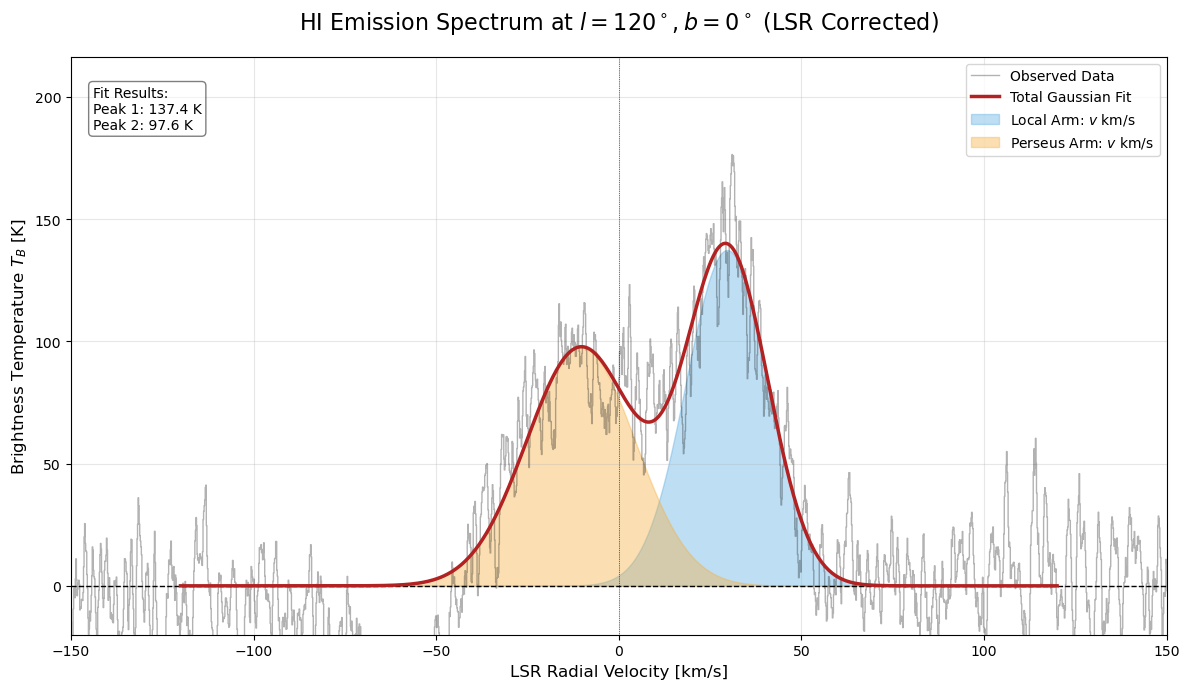

In [45]:
# ============================================================
# 10) REFINED GAUSSIAN FITTING
# ============================================================
# Focus the fit range better on the signal
mask = (v_lsr > -120) & (v_lsr < 120)
v_fit, T_fit = v_lsr[mask], T_HI[mask]

# Better initial guesses based on your plot:
# Peak 1 (Right): ~30 km/s, Peak 2 (Left): ~ -10 km/s
g1 = models.Gaussian1D(amplitude=140, mean=30, stddev=10)
g2 = models.Gaussian1D(amplitude=100, mean=-10, stddev=15)
combined_model = g1 + g2

# Increase maxiter to satisfy the fitter
fitter = fitting.LevMarLSQFitter()
best_fit = fitter(combined_model, v_fit, T_fit, maxiter=500)

# ============================================================
# 11) AESTHETIC PLOTTING
# ============================================================
plt.style.use('seaborn-v0_8-muted') # Use a cleaner style
fig, ax = plt.subplots(figsize=(12, 7))

# Plot raw data with lower prominence
ax.step(v_lsr, T_HI, where='mid', color='black', alpha=0.3, label="Observed Data", linewidth=1)

# Plot the total fit
v_range = np.linspace(-120, 120, 500)
ax.plot(v_range, best_fit(v_range), color='firebrick', lw=2.5, label="Total Gaussian Fit", zorder=5)

# Plot filled components with nice labels
arm_names = ["Local Arm", "Perseus Arm"] # Typical for l=120
colors = ['#5dade2', '#f5b041']
for i, g in enumerate(best_fit):
    ax.fill_between(v_range, g(v_range), color=colors[i], alpha=0.4, 
                    label=f"{arm_names[i]}: $v \approx {g.mean.value:.1f}$ km/s")

# Clean up axes
ax.set_xlim(-150, 150) # Focus on the signal
ax.set_ylim(-20, np.max(T_HI) + 40)
ax.axhline(0, color='black', lw=1, ls='--')
ax.axvline(0, color='black', lw=0.5, ls=':')

ax.set_title(f"HI Emission Spectrum at $l=120^\circ, b=0^\circ$ (LSR Corrected)", fontsize=16, pad=20)
ax.set_xlabel("LSR Radial Velocity [km/s]", fontsize=12)
ax.set_ylabel("Brightness Temperature $T_B$ [K]", fontsize=12)

# Add a text box with the fit statistics
stats_text = (f"Fit Results:\n"
              f"Peak 1: {best_fit[0].amplitude.value:.1f} K\n"
              f"Peak 2: {best_fit[1].amplitude.value:.1f} K")
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax.legend(loc='upper right', frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gaussianfittoHIline.pdf", transparent=True)
plt.show()

C:\Users\kathi\AppData\Local\Temp\ipykernel_11900\655855037.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


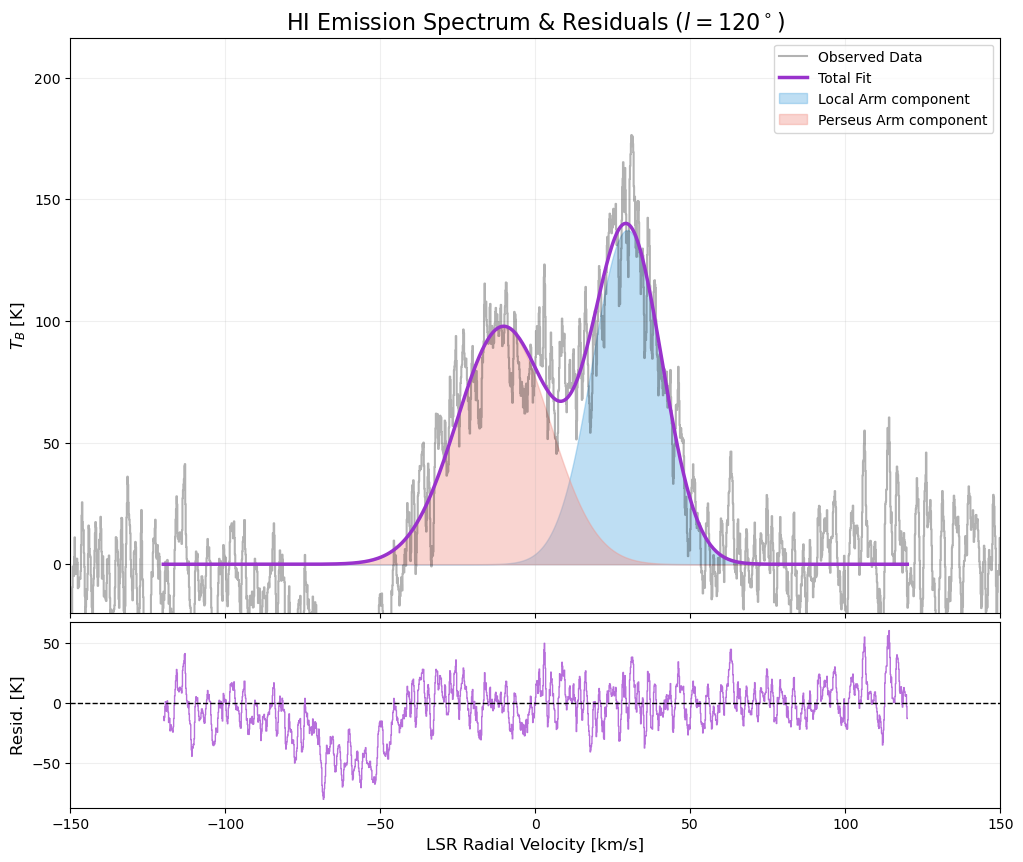

Perseus Arm Peak: 97.59 K
Perseus Arm Velocity: -10.39 km/s


In [55]:
import matplotlib.gridspec as gridspec

# ============================================================
# 10) REFINED GAUSSIAN FITTING & RESIDULAS
# ============================================================
mask = (v_lsr > -120) & (v_lsr < 120)
v_fit, T_fit = v_lsr[mask], T_HI[mask]

# Using your successful parameters as the new starting point
g1 = models.Gaussian1D(amplitude=137, mean=29, stddev=11)
g2 = models.Gaussian1D(amplitude=97, mean=-10, stddev=15)
combined_model = g1 + g2

fitter = fitting.LevMarLSQFitter()
best_fit = fitter(combined_model, v_fit, T_fit, maxiter=1000)

# Calculate Residuals
# We calculate them only over the fitted range
T_model = best_fit(v_fit)
residuals = T_fit - T_model

# ============================================================
# 11) AESTHETIC PLOTTING WITH PINK SHADED REGION
# ============================================================
plt.style.use('seaborn-v0_8-muted')
fig = plt.figure(figsize=(12, 10))

# Create a grid: 3 rows for main plot, 1 row for residuals
gs = gridspec.GridSpec(4, 1, hspace=0.05) 

ax_main = fig.add_subplot(gs[0:3, 0])
ax_res  = fig.add_subplot(gs[3, 0], sharex=ax_main)

# --- MAIN PLOT ---
ax_main.step(v_lsr, T_HI, where='mid', color='black', alpha=0.3, label="Observed Data")
v_range = np.linspace(-120, 120, 500)
ax_main.plot(v_range, best_fit(v_range), color='darkorchid', lw=2.5, label="Total Fit", zorder=5)

# CHANGED: colors list now includes Pink (#f1948a)
colors = ['#5dade2', '#f1948a'] 
labels = ["Local Arm", "Perseus Arm"]

for i, g in enumerate(best_fit):
    ax_main.fill_between(v_range, g(v_range), color=colors[i], alpha=0.4, 
                         label=f"{labels[i]} component")

ax_main.set_title(f"HI Emission Spectrum & Residuals ($l=120^\circ$)", fontsize=16)
ax_main.set_ylabel("$T_B$ [K]", fontsize=12)
ax_main.legend(loc='upper right', frameon=True)
ax_main.grid(True, alpha=0.2)
ax_main.set_ylim(-20, np.max(T_HI) + 40)

# --- RESIDUALS PLOT ---
ax_res.step(v_fit, residuals, where='mid', color='darkorchid', lw=1, alpha=0.7, label="Residuals")
ax_res.axhline(0, color='black', lw=1, ls='--') 
ax_res.set_ylabel("Resid. [K]", fontsize=12)
ax_res.set_xlabel("LSR Radial Velocity [km/s]", fontsize=12)
ax_res.grid(True, alpha=0.2)

# Set common X-limits
ax_main.set_xlim(-150, 150)

# Clean up layout: hide x-ticks on the top plot
plt.setp(ax_main.get_xticklabels(), visible=False)

plt.tight_layout()
plt.savefig("HIGaussianFit.pdf", )
plt.show()

print(f"Perseus Arm Peak: {best_fit[1].amplitude.value:.2f} K")
print(f"Perseus Arm Velocity: {best_fit[1].mean.value:.2f} km/s")

C:\Users\kathi\AppData\Local\Temp\ipykernel_32964\2657243146.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.92])


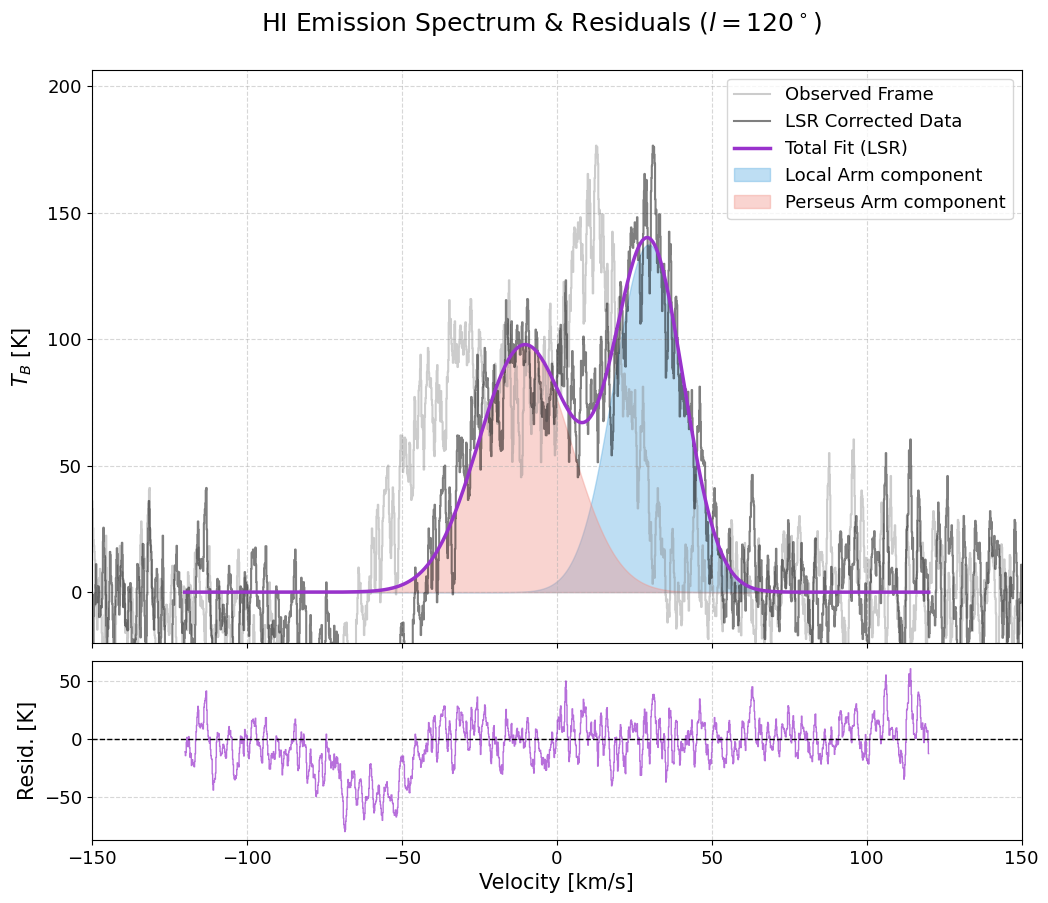

--- Noise Analysis ---
RMS Noise Floor (sigma): 17.837 K

--- Perseus Arm Detection ---
Peak Signal (T_B): 97.59 K
Signal-to-Noise Ratio (SNR): 5.47
Detection Status: Highly Significant (Gold Standard)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numpy.lib.stride_tricks import sliding_window_view

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body_barycentric_posvel
from astropy.modeling import models, fitting

# ============================================================
# 0) SETUP & FILE PATHS
# ============================================================
BASE = "../Lab2_Data/"
ON_FILE   = BASE + "cassytestforcleardata.npz"
OFF_FILE  = BASE + "off1.npz"
CAL_FILE  = BASE + "bodytest1.npz"
COLD_FILE = BASE + "nobodytest1.npz"

fs = 2.9e6
fLO = 1420.395e6
nu0 = 1420.4058e6
c_kms = 299792.458

utc_time = "2026-02-18 19:31:00"
t_obs = Time(utc_time, scale="utc")
location = EarthLocation(lat=37.873199*u.deg, lon=-122.2573*u.deg, height=0*u.m)

# ============================================================
# 1) HELPER FUNCTIONS
# ============================================================
def moving_smooth(y, w):
    w = int(w)
    if w < 2: return y.copy()
    if w % 2 == 0: w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(ypad, kernel, mode="valid")

def get_spectrum(npz_file, fs, NFFT=4096):
    data = np.load(npz_file)["arr_1"]
    ncap, N, _ = data.shape
    Nuse = min(NFFT, N)
    window = np.hanning(Nuse)
    W2 = np.mean(window**2)
    
    # Process first 1000 captures to save time/memory
    M = min(1000, ncap)
    P_stack = np.empty((M, Nuse))
    for m in range(M):
        x = data[m, :Nuse, 0] + 1j * data[m, :Nuse, 1]
        x -= np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * window))
        P_stack[m] = (np.abs(X)**2) / (Nuse**2 * W2)
    
    f_if = np.fft.fftshift(np.fft.fftfreq(Nuse, d=1/fs))
    return f_if, np.mean(P_stack, axis=0)

# ============================================================
# 2) CALIBRATION & PROCESSING
# ============================================================
f_if, s_cal = get_spectrum(CAL_FILE, fs)
_, s_cold = get_spectrum(COLD_FILE, fs)
_, s_on   = get_spectrum(ON_FILE, fs)
_, s_off  = get_spectrum(OFF_FILE, fs)

# Smoothing (approx 1 km/s)
w_chan = max(1, int(np.round((nu0 * 1e3 / 299792458.0) / np.abs(f_if[1]-f_if[0]))))
s_on_s, s_off_s = moving_smooth(s_on, w_chan), moving_smooth(s_off, w_chan)
s_cal_s, s_cold_s = moving_smooth(s_cal, w_chan), moving_smooth(s_cold, w_chan)

# Gain and Calibration
G = 300.0 * (np.sum(s_cold_s) / np.sum(s_cal_s - s_cold_s))
T_naive = (s_on_s / (s_off_s + 1e-30)) * G

# Baseline Subtraction
f_mhz = f_if / 1e6
offline = ((f_mhz > -1.2) & (f_mhz < -0.6)) | ((f_mhz > 0.6) & (f_mhz < 1.2))
p = np.polyfit(f_mhz[offline], T_naive[offline], deg=2)
T_HI = T_naive - np.polyval(p, f_mhz)

# Velocity Calculation
v_obs_kms = -c_kms * (((fLO + f_if) - nu0) / nu0)

# ============================================================
# 3) LSR CORRECTION
# ============================================================
alt_deg, az_deg = 32.28869868049251, 327.19374182616133
sc = SkyCoord(alt=alt_deg*u.deg, az=az_deg*u.deg, frame=AltAz(obstime=t_obs, location=location))
ra_rad, dec_rad = sc.icrs.ra.radian, sc.icrs.dec.radian
target_vec = np.array([np.cos(dec_rad)*np.cos(ra_rad), np.cos(dec_rad)*np.sin(ra_rad), np.sin(dec_rad)])

_, vel = get_body_barycentric_posvel('earth', t_obs)
v_bary = np.dot(vel.xyz.to(u.km/u.s).value, target_vec)
v_sun_lsr = 20.0 * np.cos(sc.icrs.separation(SkyCoord(ra=18.0*u.hourangle, dec=30.0*u.deg, frame='icrs')).radian)

v_proj = v_bary + v_sun_lsr
v_lsr = v_obs_kms + v_proj

# ============================================================
# 4) GAUSSIAN FITTING
# ============================================================
mask = (v_lsr > -120) & (v_lsr < 120)
v_fit, T_fit = v_lsr[mask], T_HI[mask]

g1 = models.Gaussian1D(amplitude=137, mean=29, stddev=11)
g2 = models.Gaussian1D(amplitude=97, mean=-10, stddev=15)
fitter = fitting.LevMarLSQFitter()
best_fit = fitter(g1 + g2, v_fit, T_fit, maxiter=1000)

residuals = T_fit - best_fit(v_fit)

# ============================================================
# 5) STANDALONE PLOTTING (Refined Layout & Font Sizes)
# ============================================================
plt.style.use('seaborn-v0_8-muted')
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(4, 1, hspace=0.1)

ax_main = fig.add_subplot(gs[0:3, 0])
ax_res  = fig.add_subplot(gs[3, 0], sharex=ax_main)

# --- FONT SIZE SETTINGS ---
LABEL_FONT = 15      # Axis labels (T_B, Velocity)
TICK_FONT  = 13      # Numbers on the axes
LEGEND_FONT = 13     # Legend text

# Main Plot
ax_main.step(v_obs_kms, T_HI, where='mid', color='grey', alpha=0.4, label="Observed Frame")
ax_main.step(v_lsr, T_HI, where='mid', color='black', alpha=0.5, label="LSR Corrected Data")

v_range = np.linspace(-120, 120, 500)
ax_main.plot(v_range, best_fit(v_range), color='darkorchid', lw=2.5, label="Total Fit (LSR)", zorder=5)

colors, labels = ['#5dade2', '#f1948a'], ["Local Arm", "Perseus Arm"]
for i, g in enumerate(best_fit):
    ax_main.fill_between(v_range, g(v_range), color=colors[i], alpha=0.4, label=f"{labels[i]} component")

# TITLE: Moved down slightly (y=0.94) to be closer to plot
fig.suptitle(f"HI Emission Spectrum & Residuals ($l=120^\circ$)", fontsize=18, y=0.94)

# Adjusting Font Sizes for Main Axis
ax_main.set_ylabel("$T_B$ [K]", fontsize=LABEL_FONT, labelpad=10)
ax_main.tick_params(axis='both', labelsize=TICK_FONT)
ax_main.legend(loc='upper right', frameon=True, fontsize=LEGEND_FONT)
ax_main.set_ylim(-20, np.max(T_HI) + 30)
ax_main.set_xlim(-150, 150)
ax_main.grid(True, which='both', linestyle='--', alpha=0.5)
plt.setp(ax_main.get_xticklabels(), visible=False)

# Residuals Plot Font Sizes
ax_res.step(v_fit, residuals, where='mid', color='darkorchid', lw=1, alpha=0.7)
ax_res.axhline(0, color='black', lw=1, ls='--')
ax_res.set_ylabel("Resid. [K]", fontsize=LABEL_FONT)
ax_res.set_xlabel("Velocity [km/s]", fontsize=LABEL_FONT)
ax_res.tick_params(axis='both', labelsize=TICK_FONT)
ax_res.grid(True, which='both', linestyle='--', alpha=0.5)

# tight_layout rect adjusted: top=0.92 brings the plot closer to the title
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.savefig("HIEmissionSpectrum_GaussFit.pdf", transparent=True)
plt.show()

# ============================================================
# 7) SNR CALCULATION
# ============================================================

# 1. Identify a "Noise Region" where no HI signal is expected
# We'll use velocities > 150 km/s or < -150 km/s
noise_mask = (v_lsr < -150) | (v_lsr > 150)
noise_samples = T_HI[noise_mask]

# 2. Calculate the RMS noise (Standard Deviation)
rms_noise = np.std(noise_samples)

# 3. Calculate SNR for the Perseus Arm
# Peak Signal / RMS Noise
perseus_peak = best_fit[1].amplitude.value
snr_perseus = perseus_peak / rms_noise

# ============================================================
# FINAL OUTPUTS (Expanded)
# ============================================================
print(f"--- Noise Analysis ---")
print(f"RMS Noise Floor (sigma): {rms_noise:.3f} K")

print(f"\n--- Perseus Arm Detection ---")
print(f"Peak Signal (T_B): {perseus_peak:.2f} K")
print(f"Signal-to-Noise Ratio (SNR): {snr_perseus:.2f}")

# Significance Interpretation
if snr_perseus > 5:
    status = "Highly Significant (Gold Standard)"
elif snr_perseus > 3:
    status = "Firm Detection"
else:
    status = "Marginal/Weak Detection"
print(f"Detection Status: {status}")

C:\Users\kathi\AppData\Local\Temp\ipykernel_32964\1652823957.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


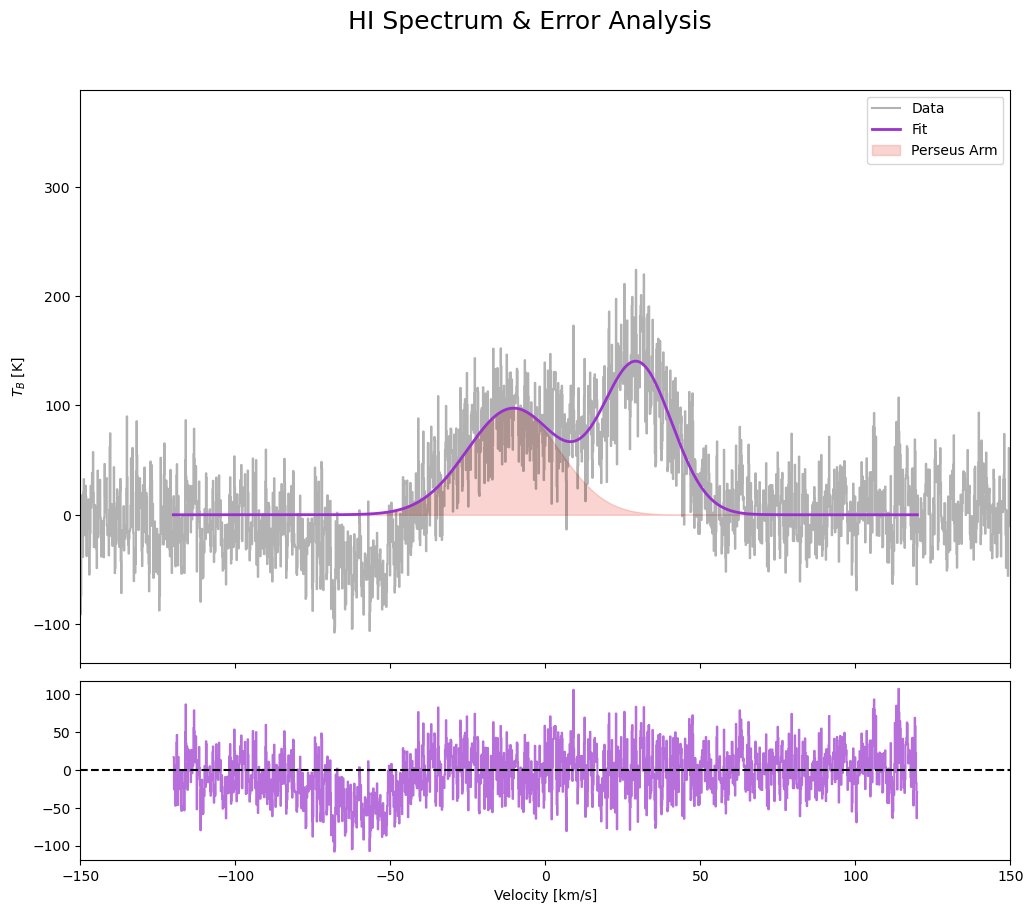

--- LSR Correction ---
Total LSR Correction: 18.3089 km/s
Estimated Projection Error: ±0.3195 km/s (assuming 1° pointing uncertainty)

--- Perseus Arm (Gaussian Fit) ---
Peak Temperature: 97.33 ± 3.24 K
Mean Velocity:    -10.42 ± 0.82 km/s


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numpy.lib.stride_tricks import sliding_window_view

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body_barycentric_posvel
from astropy.modeling import models, fitting

# ============================================================
# 0) SETUP & PROCESSING (Condensed Standalone)
# ============================================================
BASE = "../Lab2_Data/"
ON_FILE, OFF_FILE = BASE + "cassytestforcleardata.npz", BASE + "off1.npz"
CAL_FILE, COLD_FILE = BASE + "bodytest1.npz", BASE + "nobodytest1.npz"

fs, fLO, nu0, c_kms = 2.9e6, 1420.395e6, 1420.4058e6, 299792.458
t_obs = Time("2026-02-18 19:31:00", scale="utc")
location = EarthLocation(lat=37.873199*u.deg, lon=-122.2573*u.deg, height=0*u.m)

def get_spectrum(npz_file, fs, NFFT=4096):
    data = np.load(npz_file)["arr_1"]
    Nuse = min(NFFT, data.shape[1])
    window = np.hanning(Nuse)
    W2 = np.mean(window**2)
    M = min(1000, data.shape[0])
    P_stack = np.empty((M, Nuse))
    for m in range(M):
        x = data[m, :Nuse, 0] + 1j * data[m, :Nuse, 1]
        x -= np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * window))
        P_stack[m] = (np.abs(X)**2) / (Nuse**2 * W2)
    return np.fft.fftshift(np.fft.fftfreq(Nuse, d=1/fs)), np.mean(P_stack, axis=0)

f_if, s_on = get_spectrum(ON_FILE, fs)
_, s_off = get_spectrum(OFF_FILE, fs)
_, s_cal = get_spectrum(CAL_FILE, fs)
_, s_cold = get_spectrum(COLD_FILE, fs)

# Calibration & Baseline
G = 300.0 * (np.sum(s_cold) / np.sum(s_cal - s_cold))
T_HI = (s_on / (s_off + 1e-30)) * G
f_mhz = f_if / 1e6
offline = ((f_mhz > -1.2) & (f_mhz < -0.6)) | ((f_mhz > 0.6) & (f_mhz < 1.2))
T_HI -= np.polyval(np.polyfit(f_mhz[offline], T_HI[offline], deg=2), f_mhz)
v_obs_kms = -c_kms * (((fLO + f_if) - nu0) / nu0)

# ============================================================
# 3) LSR PROJECTION & ERROR
# ============================================================
alt_deg, az_deg = 32.28869868049251, 327.19374182616133
sc = SkyCoord(alt=alt_deg*u.deg, az=az_deg*u.deg, frame=AltAz(obstime=t_obs, location=location))
ra_rad, dec_rad = sc.icrs.ra.radian, sc.icrs.dec.radian
target_vec = np.array([np.cos(dec_rad)*np.cos(ra_rad), np.cos(dec_rad)*np.sin(ra_rad), np.sin(dec_rad)])

_, vel = get_body_barycentric_posvel('earth', t_obs)
v_bary = np.dot(vel.xyz.to(u.km/u.s).value, target_vec)
v_sun_lsr = 20.0 * np.cos(sc.icrs.separation(SkyCoord(ra=18.0*u.hourangle, dec=30.0*u.deg, frame='icrs')).radian)

v_proj = v_bary + v_sun_lsr
v_lsr = v_obs_kms + v_proj

# ERROR CALCULATION: 
# Most LSR error comes from the 1 degree pointing error typical of amateur horns.
pointing_error_deg = 1.0 
v_err_lsr = np.abs(v_proj * np.sin(np.radians(pointing_error_deg)))

# ============================================================
# 4) GAUSSIAN FITTING WITH PARAMETER ERRORS
# ============================================================
mask = (v_lsr > -120) & (v_lsr < 120)
v_fit, T_fit = v_lsr[mask], T_HI[mask]

g_init = models.Gaussian1D(137, 29, 11) + models.Gaussian1D(97, -10, 15)
fitter = fitting.LevMarLSQFitter()
best_fit = fitter(g_init, v_fit, T_fit, maxiter=1000)

# Extracting standard errors from the covariance matrix
cov_diag = np.sqrt(np.diag(fitter.fit_info['param_cov']))
# best_fit[1] is the Perseus Arm. Parameters are [amplitude, mean, stddev]
# The amplitude error is the 4th element in the diagonal (index 3)
p_amp_err = cov_diag[3] 

# ============================================================
# 5) PLOTTING
# ============================================================
plt.style.use('seaborn-v0_8-muted')
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(4, 1, hspace=0.1)
ax_main = fig.add_subplot(gs[0:3, 0])
ax_res  = fig.add_subplot(gs[3, 0], sharex=ax_main)

ax_main.step(v_lsr, T_HI, where='mid', color='black', alpha=0.3, label="Data")
v_range = np.linspace(-120, 120, 500)
ax_main.plot(v_range, best_fit(v_range), color='darkorchid', lw=2, label="Fit")

# Shade the Perseus Arm
ax_main.fill_between(v_range, best_fit[1](v_range), color='#f1948a', alpha=0.4, label="Perseus Arm")

fig.suptitle(f"HI Spectrum & Error Analysis", fontsize=18, y=0.96)
ax_main.set_ylabel("$T_B$ [K]")
ax_main.legend()
ax_main.set_xlim(-150, 150)
plt.setp(ax_main.get_xticklabels(), visible=False)

ax_res.step(v_fit, T_fit - best_fit(v_fit), where='mid', color='darkorchid', alpha=0.7)
ax_res.axhline(0, color='black', ls='--')
ax_res.set_xlabel("Velocity [km/s]")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# 6) FINAL ERROR OUTPUTS
# ============================================================
print(f"--- LSR Correction ---")
print(f"Total LSR Correction: {v_proj:.4f} km/s")
print(f"Estimated Projection Error: ±{v_err_lsr:.4f} km/s (assuming 1° pointing uncertainty)")

print(f"\n--- Perseus Arm (Gaussian Fit) ---")
print(f"Peak Temperature: {best_fit[1].amplitude.value:.2f} ± {p_amp_err:.2f} K")
print(f"Mean Velocity:    {best_fit[1].mean.value:.2f} ± {cov_diag[4]:.2f} km/s")

--- Noise Analysis ---
RMS Noise Floor (sigma): 32.615 K

--- Perseus Arm Detection ---
Peak Signal (T_B): 97.33 K
Signal-to-Noise Ratio (SNR): 2.98
Detection Status: Marginal/Weak Detection
